# Motivation: Hands-on Statistical Computing



## Why this session?

-   Modern data work relies heavily on statistical reasoning, not just
    computation.
-   Tools can compute statistics instantly, but **understanding their
    meaning** is essential.
-   Real-world questions often involve:
    -   Identifying relationships between variables
    -   Measuring strength of association
    -   Understanding uncertainty and randomness
    -   Interpreting patterns correctly



## What you will learn

-   Intuition behind covariance and correlation
-   Understanding of probability distributions in real data
-   Ability to visualize statistical behavior
-   Confidence in interpreting statistical outputs



### basic imports + helper plots

In [ ]:
# Core imports (Colab usually has these installed)
import numpy as np          # Numerical operations
import matplotlib.pyplot as plt # Data visualization
from scipy import stats     # Statistical distributions

# Clean up output formatting (4 decimal places, no scientific notation)
np.set_printoptions(precision=4, suppress=True)

# Modern generator for reproducible results (replacing legacy seed)
rng = np.random.default_rng(42)

In [ ]:
def scatter_xy(x, y, title="", xlabel="x", ylabel="y"):
    plt.figure()
    plt.scatter(x, y, alpha=0.7)  # Semi-transparent to reveal point density
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)     # Subtle grid for better readability
    plt.show()

def hist_with_lines(data, title="", bins=30):
    plt.figure()
    # density=True normalizes the histogram to an area of 1
    plt.hist(data, bins=bins, density=True, alpha=0.7)
    plt.axvline(np.mean(data), linewidth=2, label="Mean")     # Visual center of mass
    plt.axvline(np.median(data), linewidth=2, label="Median") # Middle value marker
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

def hist_with_pdf(data, dist, title="", bins=40, xlim=None):
    plt.figure()
    plt.hist(data, bins=bins, density=True, alpha=0.6, label="Empirical (hist)")

    # Generate x-values for the smooth PDF curve
    xs = np.linspace(np.min(data), np.max(data), 400)
    if xlim is not None:
        xs = np.linspace(xlim[0], xlim[1], 400)

    plt.plot(xs, dist.pdf(xs), linewidth=2, label="Theoretical PDF") # Overlay distribution curve
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# 1) Descriptive Statistics  (single-variable)



Before we measure **relationships between variables** (covariance/correlation), we need to be comfortable describing **one variable**.

In data work, descriptive statistics help you answer:
- Where is the data centered? (mean/median/mode)
- How spread out is it? (variance/std)
- What do typical ranges look like? (quantiles/percentiles)
- What does the distribution *look* like? (histograms)

We'll use **two datasets**:
1. A roughly symmetric dataset (Normal-like)
2. A skewed dataset (Exponential-like)



### Data preparation

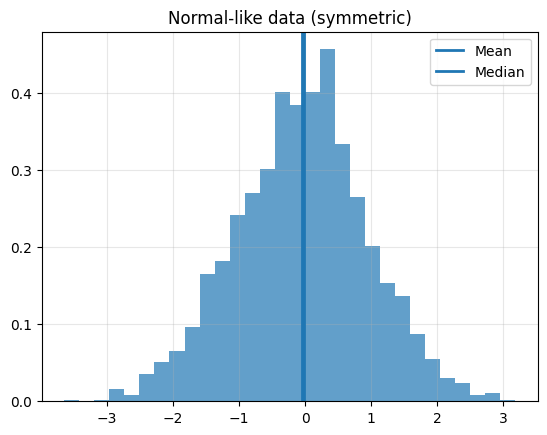

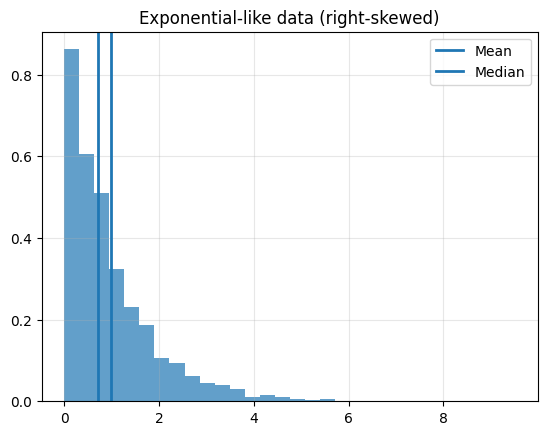

In [ ]:
# Create two datasets: symmetric vs skewed
normal_data = rng.normal(loc=0, scale=1, size=2000)      # Balanced bell curve
skewed_data = rng.exponential(scale=1.0, size=2000)     # Long tail to the right

# Plotting symmetric data where mean ≈ median
hist_with_lines(normal_data, title="Normal-like data (symmetric)")

# Plotting skewed data to show the mean being pulled by the tail
hist_with_lines(skewed_data, title="Exponential-like data (right-skewed)")

### Measures of center: mean, median, mode



**Mean**
- The arithmetic average.
- Sensitive to outliers and skew.

**Median**
- Middle value after sorting.
- More robust to outliers/skew.

**Mode**
- Most frequent value.
- Most meaningful for discrete/categorical data; for continuous data it depends on binning.


##Task:
Write simple code to compute mean, median , mode of a given array

In [ ]:
def calculate_mean (arr):
  # write your logic here




def calculate_median(arr):
  # write your logic here


def caclulate_mode(arr):
  # write your logic here



data = [1, 2, 2, 3, 4, 7, 9, 11, 2, 1, 12, 5, 4, 4, 3, 12, 2, 11, 12, 15, 9, 2, 10, 7, 1]
print(calculate_mean(data))
print(calculate_median(data))
print(caclulate_mode(data))

IndentationError: expected an indented block after function definition on line 1 (50598774.py, line 5)

In [ ]:
def describe_center(x, name="data"):
    x = np.asarray(x)        # Ensure input is a NumPy array
    mean = np.mean(x)        # Sensitive to outliers/skew
    median = np.median(x)    # Robust to outliers (50th percentile)

    # Print formatted summary for quick comparison
    print(f"{name}: mean={mean:.4f}, median={median:.4f}")

# Compare centers for symmetric vs. skewed distributions
describe_center(normal_data, "normal_data")
describe_center(skewed_data, "skewed_data")

NameError: name 'normal_data' is not defined

![Mean Median Mode Relationship](https://github.com/Rajdeep-G/study-material-classes/blob/main/NSSTA-data-analytics/img/mmm.png?raw=true)

### Mode for continuous data (practical approach)
For continuous values, exact repeats are rare. A practical "mode-like" measure is:
- Bin the data (histogram)
- Pick the bin with the highest count (peak)

We'll compute that below.

In [ ]:
def binned_mode(x, bins=30):
    # Group data into frequency counts and bin boundaries
    counts, edges = np.histogram(x, bins=bins)

    # Find the index of the bin with the highest count
    idx = np.argmax(counts)

    # Return the midpoint of the most frequent bin as an approximate mode
    return (edges[idx] + edges[idx+1]) / 2

# Calculate the "peak" for both datasets
print("Binned mode (normal):", binned_mode(normal_data))
print("Binned mode (skewed):", binned_mode(skewed_data))

Binned mode (normal): 0.3341593024582359
Binned mode (skewed): 0.15882025198981078


### Measures of spread: variance and standard deviation

### Variance
Average squared deviation from the mean.

### Standard deviation
Square root of variance; measured in the same units as the data.

**Why we care:** standard deviation is used to normalize covariance into correlation.


In [ ]:
def describe_spread(x, name="data"):
    x = np.asarray(x)
    var_pop = np.var(x)             # Biased variance (N in denominator)
    var_sample = np.var(x, ddof=1)  # Unbiased estimator (N-1 in denominator)
    std_sample = np.std(x, ddof=1)  # Square root of sample variance

    # Output spreads to compare variability across datasets
    print(f"{name}: var(pop)={var_pop:.4f}, var(sample)={var_sample:.4f}, std(sample)={std_sample:.4f}")

# Calculate spread for symmetric vs. skewed data
describe_spread(normal_data, "normal_data")
describe_spread(skewed_data, "skewed_data")

normal_data: var(pop)=1.0036, var(sample)=1.0041, std(sample)=1.0021
skewed_data: var(pop)=0.9457, var(sample)=0.9461, std(sample)=0.9727


### Quantiles / percentiles

Quantiles split sorted data into equal-sized parts.
Common ones:
- **Quartiles**: 25th, 50th (median), 75th percentile
- **Percentiles**: e.g., 90th percentile means 90% of data is below it

In practice, quantiles help define robust ranges (especially for skewed data).


In [ ]:
def show_quantiles(x, name="data"):
    # Common cut-off points (IQR boundaries + upper tail thresholds)
    qs = [0.25, 0.5, 0.75, 0.9, 0.95]
    vals = np.quantile(x, qs) # Interpolates between points if necessary

    print(name)
    for q, v in zip(qs, vals):
        # Aligned printing for easy vertical scanning
        print(f"  q={q:>4}: {v:.4f}")

# Quantiles show the symmetric spread of Normal data
show_quantiles(normal_data, "normal_data")

# Quantiles reveal the "long tail" of Exponential data
show_quantiles(skewed_data, "skewed_data")

normal_data
  q=0.25: -0.7200
  q= 0.5: -0.0225
  q=0.75: 0.5994
  q= 0.9: 1.2265
  q=0.95: 1.5796
skewed_data
  q=0.25: 0.2801
  q= 0.5: 0.7082
  q=0.75: 1.3511
  q= 0.9: 2.2655
  q=0.95: 2.9278


So far we described **one variable at a time**.

But real datasets are multi-column:
- Does feature A increase when feature B increases?
- Are they related linearly or only monotonically?
- How strong is the relationship?

That’s where **covariance** and **correlation** come in.


# 2) Data relationships: what are we measuring?




When we say two variables are “related”, we might mean:
- **Linear relationship**: points roughly form a line (positive or negative slope).
- **Monotonic relationship**: as one increases, the other tends to increase (or decrease), but not necessarily in a straight line.
- **No clear relationship**: scatter looks like a cloud.

We'll generate four datasets to build intuition.

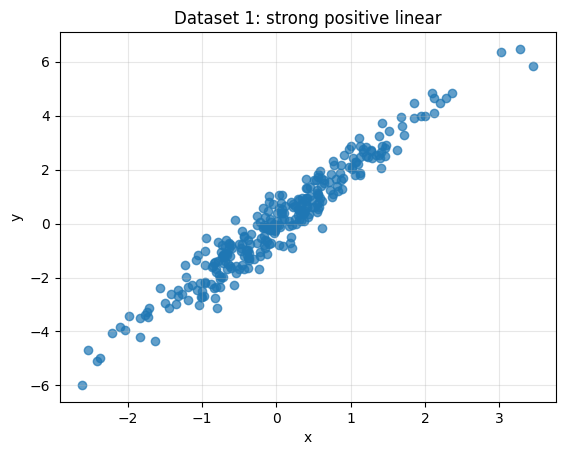

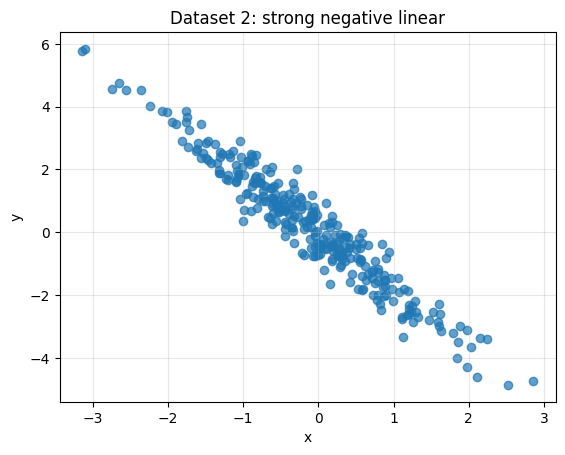

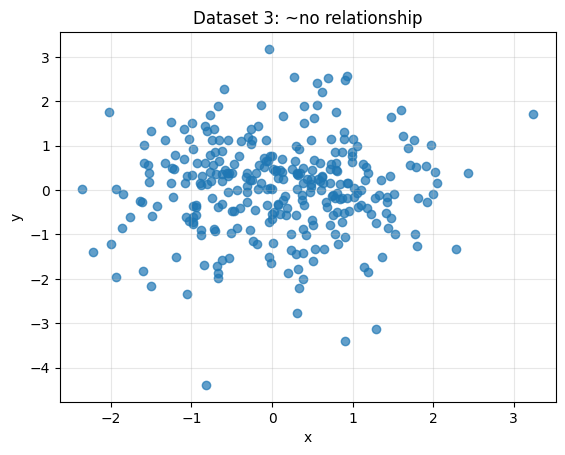

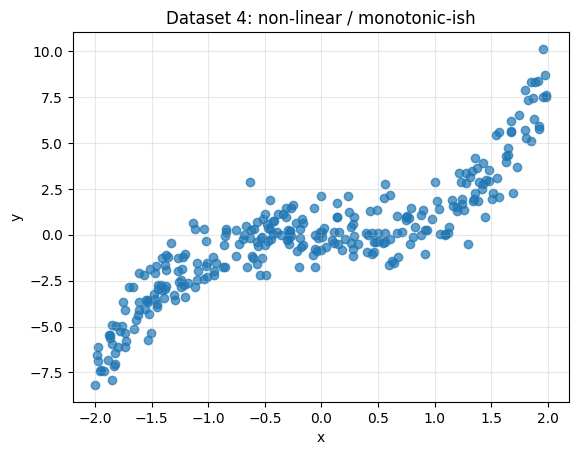

In [ ]:
n = 300

# 1) Strong positive linear: High slope, low noise
x1 = rng.normal(0, 1, n)
y1 = 2.0 * x1 + rng.normal(0, 0.5, n)

# 2) Strong negative linear: Inverse relationship with low noise
x2 = rng.normal(0, 1, n)
y2 = -1.8 * x2 + rng.normal(0, 0.5, n)

# 3) No relationship: Independent random variables (uncorrelated)
x3 = rng.normal(0, 1, n)
y3 = rng.normal(0, 1, n)

# 4) Non-linear but monotonic: Cubic function creates a curve
x4 = rng.uniform(-2, 2, n)
y4 = x4**3 + rng.normal(0, 1.0, n)  # Pearson might struggle; Spearman will excel

# Visualize all synthetic behaviors
scatter_xy(x1, y1, title="Dataset 1: strong positive linear")
scatter_xy(x2, y2, title="Dataset 2: strong negative linear")
scatter_xy(x3, y3, title="Dataset 3: ~no relationship")
scatter_xy(x4, y4, title="Dataset 4: non-linear / monotonic-ish")

- Linear relationship with outliers: Sometimes two variables are clearly linearly related,  but a few extreme points (outliers) distort the picture.

- Non-monotonic relationship: Here, y depends on x in a quadratic way.

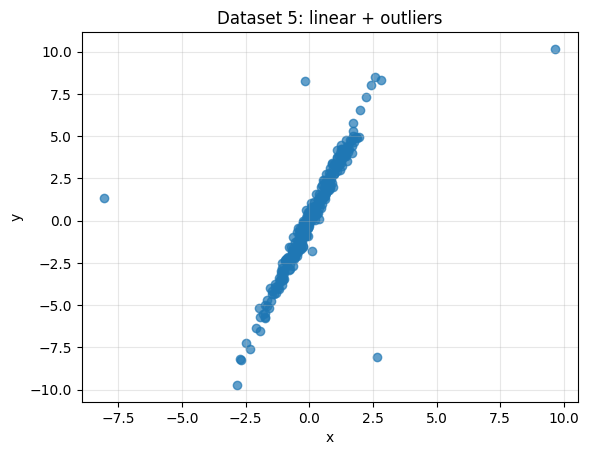

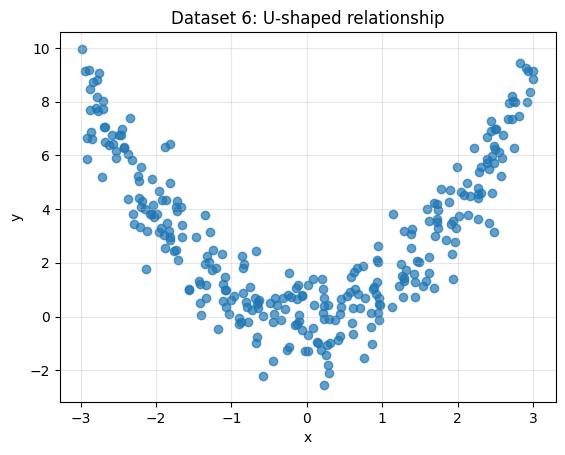

In [ ]:
# 5) Linear with outliers
x5 = rng.normal(0, 1, n)
y5 = 3 * x5 + rng.normal(0, 0.4, n)

# Inject extreme outliers: select 5 random points to displace
idx = rng.choice(n, size=5, replace=False)
x5[idx] += rng.normal(0, 8, size=5)     # Severe horizontal shift
y5[idx] += rng.normal(0, 8, size=5)     # Severe vertical shift

scatter_xy(x5, y5, title="Dataset 5: linear + outliers")


# 6) Non-monotonic relationship: Parabolic curve
x6 = rng.uniform(-3, 3, n)
y6 = x6**2 + rng.normal(0, 1.0, n)      # Symmetrical U-shape

scatter_xy(x6, y6, title="Dataset 6: U-shaped relationship")

- Threshold / step relationship: y changes suddenly when x crosses a threshold.

- Clustered groups: Sometimes data comes from different subgroups.
Within each group, the relationship may differ.


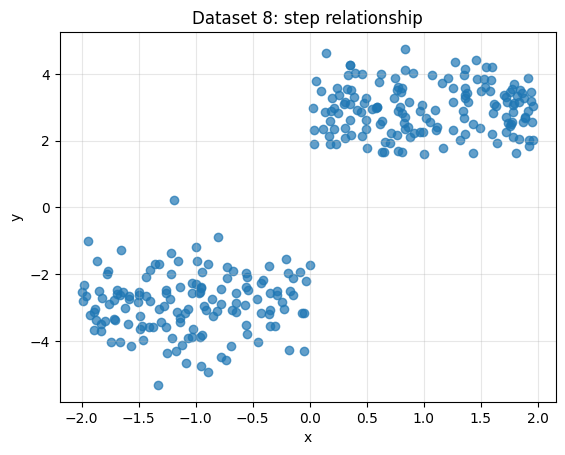

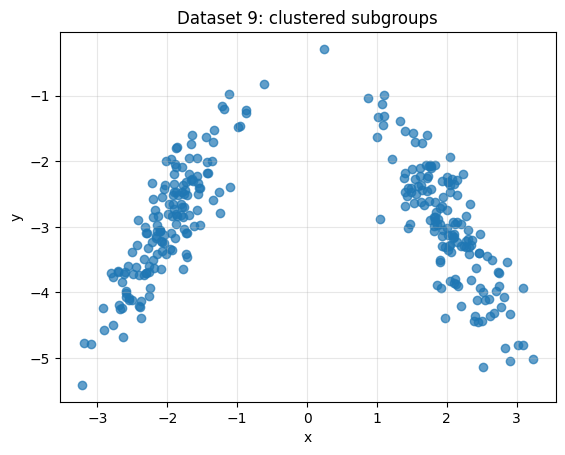

In [ ]:
# 8) step relationship
x8 = rng.uniform(-2, 2, n)
# Binary jump at zero with added gaussian noise
y8 = np.where(x8 > 0, 3, -3) + rng.normal(0, 0.8, n)

scatter_xy(x8, y8, title="Dataset 8: step relationship")

# 9) Clustered groups
# Create first cluster with positive correlation
x9a = rng.normal(-2, 0.5, n//2)
y9a = 1.5 * x9a + rng.normal(0, 0.5, n//2)

# Create second cluster with negative correlation
x9b = rng.normal(2, 0.5, n//2)
y9b = -1.5 * x9b + rng.normal(0, 0.5, n//2)

# Merge clusters into a single heterogeneous dataset
x9 = np.concatenate([x9a, x9b])
y9 = np.concatenate([y9a, y9b])

scatter_xy(x9, y9, title="Dataset 9: clustered subgroups")

# 3) Covariance




Covariance measures **joint variability**: do two variables increase/decrease together?

For two variables \(X, Y\):
- If large values of \(X\) tend to occur with large values of \(Y\), covariance tends to be **positive**.
- If large \(X\) tends to occur with small \(Y\), covariance tends to be **negative**.

### Key property
**Covariance depends on scale**.
- If you multiply \(X\) by 1000 (change units), covariance changes by 1000.
- That makes covariance hard to compare across different units.

So covariance is great internally (e.g., covariance matrix), but correlation is usually better for comparing strength.

In [ ]:
def sample_cov(x, y):
    # Sample covariance with (n-1) in denominator
    x = np.asarray(x)
    y = np.asarray(y)
    return np.sum((x - x.mean()) * (y - y.mean())) / (len(x) - 1)

# Compare covariance on original vs scaled data
x = x1
y = y1

cov_xy = sample_cov(x, y)
cov_scaled = sample_cov(1000*x, y)  # scaling x changes covariance

cov_xy, cov_scaled


(np.float64(1.973156073737117), np.float64(1973.1560737371171))

### Covariance of Independent Variables

Independent ⇒ covariance ≈ 0 (in large samples)

But covariance = 0 does NOT imply independence

In [ ]:
n=1000
x_ind = rng.normal(0,1,n)
y_ind = rng.normal(0,1,n)

sample_cov(x_ind, y_ind)

np.float64(0.04474748134537085)

### Covariance matrix
For multiple variables, we use a **covariance matrix**.

If we have features \(X_1, X_2, ..., X_d\), covariance matrix is a \(d\times d\) matrix where:
- Diagonal = variances
- Off-diagonal = covariances

**NumPy** provides `np.cov`.

In [ ]:
# Create a small 3-feature dataset
A = rng.normal(0, 1, n)
B = 0.7*A + rng.normal(0, 0.7, n)
C = -0.5*A + rng.normal(0, 0.7, n)

X = np.vstack([A, B, C])  # shape (3, n) where each row is a variable
cov_mat = np.cov(X, bias=False)  # bias=False -> sample covariance (n-1)

cov_mat


array([[ 1.0403,  0.7331, -0.5229],
       [ 0.7331,  0.979 , -0.3599],
       [-0.5229, -0.3599,  0.7672]])

### Visualizing covariance matrix (heatmap)
A heatmap helps quickly see which pairs move together.

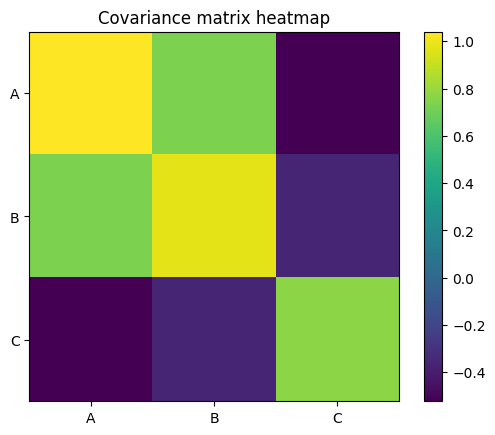

In [ ]:
plt.figure()
plt.imshow(cov_mat, interpolation="nearest")
plt.title("Covariance matrix heatmap")
plt.colorbar()
plt.xticks([0,1,2], ["A","B","C"])
plt.yticks([0,1,2], ["A","B","C"])
plt.show()


## Task — Scaling Experiment (Units and Scale)

### Scenario
You are analyzing a marketing dataset.

- `ad_spend_rupees`: Daily ad spend in **₹**
- `sales`: Daily sales in **units sold**

It is reasonable to expect that higher ad spend leads to higher sales, but with noise.

### Task
1. Compute the **sample covariance** between `ad_spend_rupees` and `sales`.
2. Now convert ad spend from **₹ to ₹ thousands** by scaling:  
   `ad_spend_thousands = ad_spend_rupees / 1000`
3. Re-compute covariance between `ad_spend_thousands` and `sales`.
4. Repeat for scaling factors `[0.1, 1, 10, 100, 1000]` and observe:
   - How does **covariance** change?


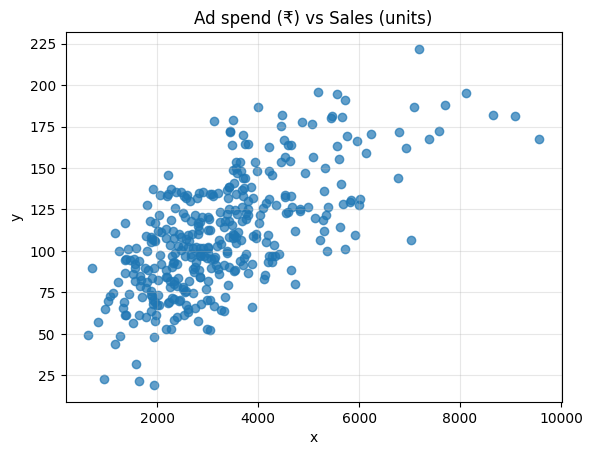

ad_spend_rupees range: 632.6625461870486 to 9566.072236202952
sales range: 19.221217916517105 to 221.7978059366589


In [ ]:
# Dataset: ad spend (₹) vs sales (units)
n = 365  # one year of daily data

# Ad spend in rupees (right-skewed: some days spend is much higher)
ad_spend_rupees = rng.lognormal(mean=8.0, sigma=0.45, size=n)  # roughly ~₹3k to ₹25k typical range

# Sales increases with ad spend but saturates (realistic) + noise
# Saturation makes it realistic but still strongly monotonic.
base_sales = 60
sales = base_sales + 0.015 * ad_spend_rupees + rng.normal(0, 25, size=n)

# Quick look
scatter_xy(ad_spend_rupees, sales, title="Ad spend (₹) vs Sales (units)")
print("ad_spend_rupees range:", ad_spend_rupees.min(), "to", ad_spend_rupees.max())
print("sales range:", sales.min(), "to", sales.max())

In [ ]:
scales = [0.1, 1, 10, 100, 1000]

# write your code below



# 4) Correlation



Correlation is a **normalized** covariance. The most common is **Pearson correlation**:



### Why it’s useful
- Scale-free (unitless)
- Comparable across pairs
- Range: **-1 to +1**

### Interpretation (rule-of-thumb, context matters)
- \(|r|\) close to 1: strong linear relationship
- \(|r|\) close to 0: weak linear relationship

NumPy: `np.corrcoef` gives a correlation matrix.

In [ ]:
def pearson_corr_np(x, y):
    return np.corrcoef(x, y)[0, 1]

print("Pearson r (dataset1):", pearson_corr_np(x1, y1))
print("Pearson r (dataset3):", pearson_corr_np(x3, y3))
print("Pearson r (dataset4 non-linear):", pearson_corr_np(x4, y4))


Pearson r (dataset1): 0.9697898111412581
Pearson r (dataset3): 0.04161930320430512
Pearson r (dataset4 non-linear): 0.8698047333621741


### Scale invariance
Correlation does **not** change if we scale or shift variables.

In [ ]:
r1 = pearson_corr_np(x1, y1)
r2 = pearson_corr_np(1000*x1 + 5, y1)  # scale + shift x

r1, r2


(np.float64(0.9697898111412581), np.float64(0.9697898111412581))

## Correlation significance with SciPy (`pearsonr`)

### What `pearsonr` returns
- `r`: Pearson correlation coefficient
- `p-value`: under the null hypothesis of **zero** correlation (with assumptions)




In [ ]:
r, p = stats.pearsonr(x1, y1)
r, p


(np.float64(0.9697898111412583), np.float64(1.2277901421555075e-184))

### Outliers can distort Pearson correlation
Pearson is sensitive to outliers because it depends on means and variances.

We'll add a few outliers and see what happens.

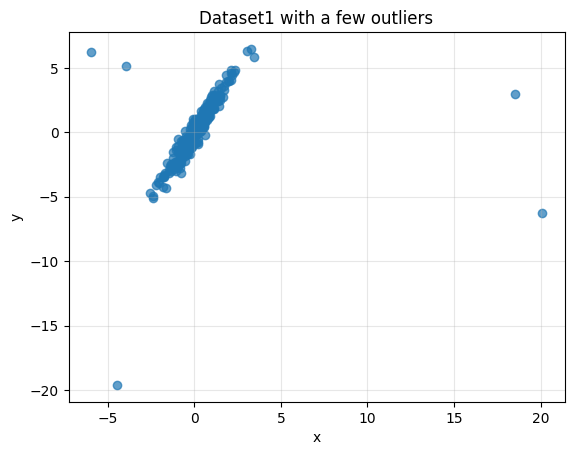

Pearson r original: 0.9697898111412583
Pearson r w/ outliers: 0.382431591017


In [ ]:
x_out = x1.copy()
y_out = y1.copy()

# Inject 3 outliers
idx = rng.choice(len(x_out), size=5, replace=False)
x_out[idx] += rng.normal(0, 10, size=5)
y_out[idx] += rng.normal(0, 10, size=5)

scatter_xy(x_out, y_out, title="Dataset1 with a few outliers")

print("Pearson r original:", stats.pearsonr(x1, y1)[0])
print("Pearson r w/ outliers:", stats.pearsonr(x_out, y_out)[0])


## Spearman correlation (rank-based)

**Spearman** correlation measures **monotonic** relationships.
- It computes Pearson correlation on **ranks**.
- More robust to outliers
- Captures monotonic non-linear patterns better than Pearson

In data work:
- Use **Pearson** for linear relationships
- Use **Spearman** when you suspect monotonic non-linearity or outliers


In [ ]:
print("Dataset4 (non-linear):")
print("Pearson :", stats.pearsonr(x4, y4)[0])
print("Spearman:", stats.spearmanr(x4, y4).correlation)


Dataset4 (non-linear):
Pearson : 0.8698047333621737
Spearman: 0.8681580906454516


## Task — Pearson vs Spearman Correlation (Which one should you trust?)

### Scenario
You are analyzing user engagement data for a mobile application.

- `session_length`: Average session duration per user (in minutes)
- `engagement_score`: An internal engagement metric (higher = more engaged)

From domain knowledge:
- Engagement tends to increase as session length increases
- The relationship may not be perfectly linear
- A few users behave abnormally (extremely long sessions)

### Tasks
1. Visualize the relationship between `session_length` and `engagement_score`.
2. Compute **Pearson correlation** and **Spearman correlation**.
3. Inject a small number of extreme outliers into `session_length`.
4. Recompute both correlations.
5. Answer:
   - Which correlation measure is more stable?
   - Which one better captures the relationship?

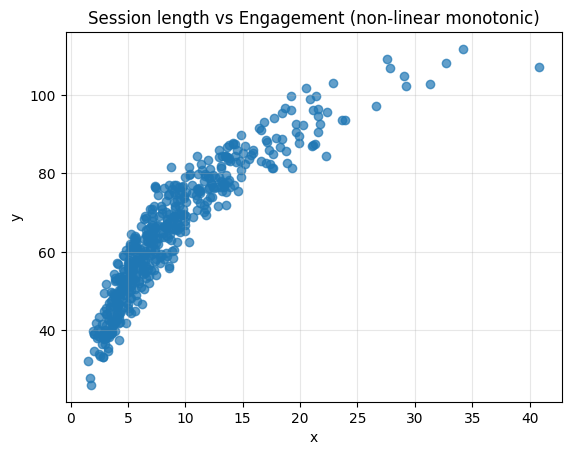

In [ ]:
# Synthetic user engagement dataset
n = 500

# Session length in minutes (right-skewed: typical user behavior)
session_length = rng.lognormal(mean=2.0, sigma=0.6, size=n)

# Engagement increases with session length but saturates (non-linear)
engagement_score = (
    30 * np.log1p(session_length)
    + rng.normal(0, 5, size=n)
)

scatter_xy(session_length, engagement_score,
           title="Session length vs Engagement (non-linear monotonic)")

In [ ]:
# write your code

# 5) Distributions


A **probability distribution** describes how a random variable takes values.

In practice:
- We use distributions to model uncertainty (noise)
- We simulate data
- We build statistical tests and confidence intervals
- We fit models (e.g., Normal errors in regression)

### SciPy’s distribution API
Most distributions in `scipy.stats` support:
- `.rvs(size=...)` sampling
- `.pdf(x)` for continuous (or `.pmf(k)` for discrete)
- `.cdf(x)` cumulative distribution
- `.mean()`, `.var()`, `.stats()`

We’ll visualize and simulate a few common ones.

## Normal distribution (Gaussian)

Normal distribution often appears due to **Central Limit Theorem**: sums/averages of many small independent effects tend to look Normal.

Parameters:
- `loc` = mean (μ)
- `scale` = standard deviation (σ)

We'll sample, plot histogram, and overlay the theoretical PDF.

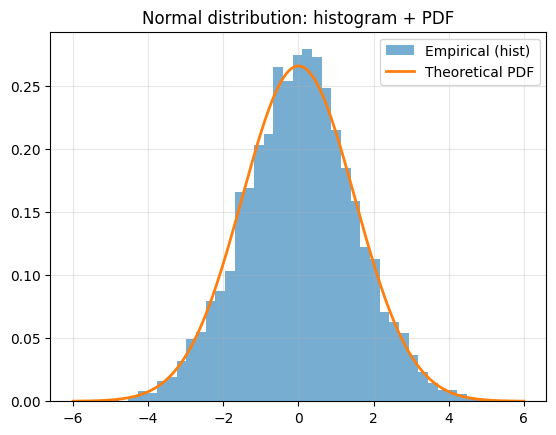

Empirical mean/std: 0.031869084686839584 1.481430534204311
Theoretical mean/std: 0.0 1.5


In [ ]:
# Define parameters for the Normal (Gaussian) distribution
mu, sigma = 0.0, 1.5
dist = stats.norm(loc=mu, scale=sigma) # Create a distribution object

# Generate 5000 random samples based on the defined distribution
data = dist.rvs(size=5000, random_state=rng)

# Overlay the theoretical curve on the actual sampled data
hist_with_pdf(data, dist, title="Normal distribution: histogram + PDF", xlim=(-6, 6))

# Compare data-derived stats (Empirical) vs. the original parameters (Theoretical)
print("Empirical mean/std:", data.mean(), data.std(ddof=1))
print("Theoretical mean/std:", dist.mean(), dist.std())

### Central Limit Theorem demo (quick)
Take many samples from a non-Normal distribution, average them, and the averages become ~Normal.

We’ll use an Exponential distribution (skewed) and average groups of size k.

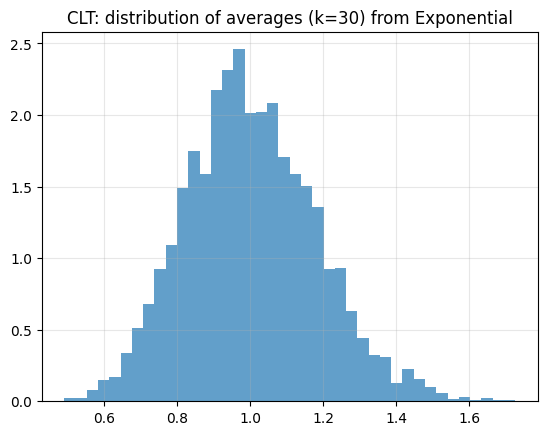

Averages: mean≈ 1.0024726551906384 std≈ 0.17957778447576683


In [ ]:
# Define parent distribution: Exponential is heavily right-skewed
exp_dist = stats.expon(scale=1.0)  # mean=1, std=1
k = 30        # Sample size per group (n >= 30 is the rule of thumb for CLT)
groups = 4000 # Number of times we repeat the sampling experiment

# Generate raw data and reshape into a matrix (rows=experiments, cols=samples)
samples = exp_dist.rvs(size=k*groups, random_state=rng).reshape(groups, k)

# Calculate the mean of each group (reducing the matrix to a vector of averages)
means = samples.mean(axis=1)

plt.figure()
# The resulting histogram of 'means' should look bell-shaped, not exponential
plt.hist(means, bins=40, density=True, alpha=0.7)
plt.title(f"CLT: distribution of averages (k={k}) from Exponential")
plt.grid(True, alpha=0.3)
plt.show()

# The mean of averages should stay near 1.0, but the std should shrink by sqrt(k)
print("Averages: mean≈", means.mean(), "std≈", means.std(ddof=1))

## Binomial distribution (discrete)

Counts the number of successes in `n` independent trials with success probability `p`.

Examples:
- Clicked vs not clicked (n users)
- Passed vs failed (n tests)

SciPy uses `.pmf(k)` for discrete distributions.

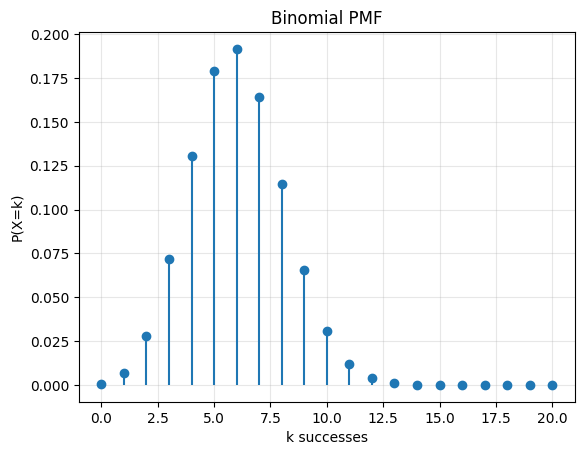

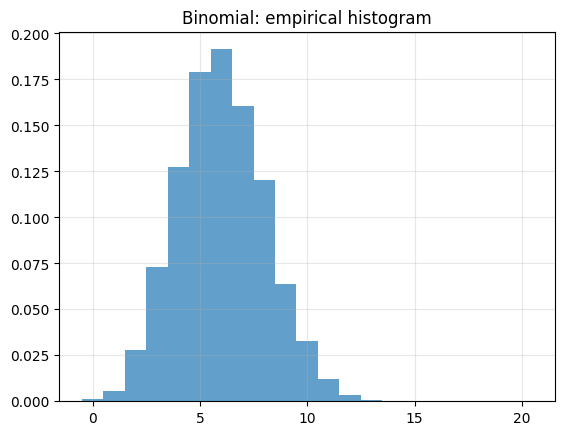

Empirical mean/var: 6.0128 4.2166794958991805
Theoretical mean/var: 6.0 4.2


In [ ]:
# Parameters: 20 independent trials with a 30% success probability each
n_trials, p = 20, 0.3
binom = stats.binom(n=n_trials, p=p)

# Create an array for all possible outcomes (0 to 20 successes)
k = np.arange(0, n_trials+1)
pmf = binom.pmf(k) # Probability Mass Function (exact probabilities)

plt.figure()
# Use stem plot to emphasize that Binomial is a discrete distribution
plt.stem(k, pmf, basefmt=" ")
plt.title("Binomial PMF")
plt.xlabel("k successes")
plt.ylabel("P(X=k)")
plt.grid(True, alpha=0.3)
plt.show()

# Simulate 5000 experiments to see if they match the theory
s = binom.rvs(size=5000, random_state=rng)
plt.figure()
# Center bins at integers to align with discrete counts
plt.hist(s, bins=np.arange(-0.5, n_trials+1.5, 1), density=True, alpha=0.7)
plt.title("Binomial: empirical histogram")
plt.grid(True, alpha=0.3)
plt.show()

# Verify against formula: Mean = n*p, Var = n*p*(1-p)
print("Empirical mean/var:", s.mean(), s.var(ddof=1))
print("Theoretical mean/var:", binom.mean(), binom.var())

## Poisson distribution (counts per interval)

Models the number of events in a fixed interval when events occur with a constant rate λ.

Examples:
- Tickets per hour
- Arrivals per minute

Mean and variance are both λ.

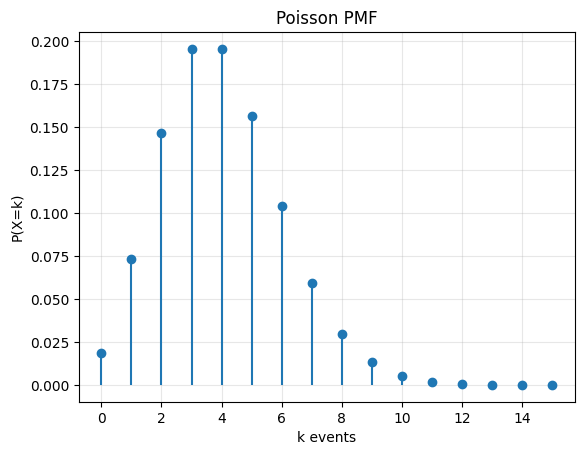

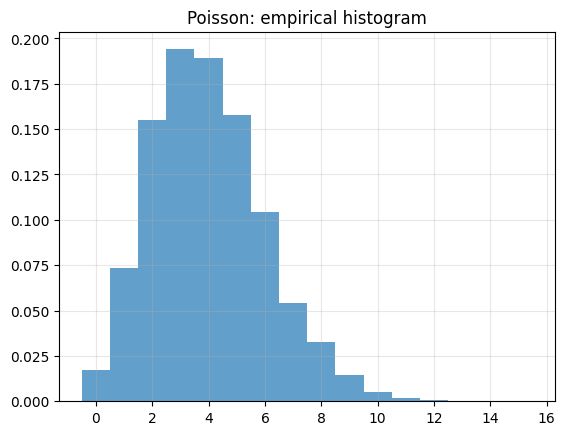

Empirical mean/var: 3.988 4.022260452090418
Theoretical mean/var: 4.0 4.0


In [ ]:
# Rate parameter (average number of events in a fixed interval)
lam = 4.0
pois = stats.poisson(mu=lam)

# Range for plotting (0 to 15 events covers most of the probability for lambda=4)
k = np.arange(0, 16)
pmf = pois.pmf(k) # Probability of exactly k events occurring

plt.figure()
plt.stem(k, pmf, basefmt=" ") # Discrete points for count-based data
plt.title("Poisson PMF")
plt.xlabel("k events")
plt.ylabel("P(X=k)")
plt.grid(True, alpha=0.3)
plt.show()

# Generate 5000 random samples to verify the model
s = pois.rvs(size=5000, random_state=rng)
plt.figure()
# Align bins to integers to match the nature of arrival counts
plt.hist(s, bins=np.arange(-0.5, 16.5, 1), density=True, alpha=0.7)
plt.title("Poisson: empirical histogram")
plt.grid(True, alpha=0.3)
plt.show()

# In a Poisson distribution, Mean == Variance == Lambda
print("Empirical mean/var:", s.mean(), s.var(ddof=1))
print("Theoretical mean/var:", pois.mean(), pois.var())